# Notebook 07 — Final Comparison and PICO Table

This is the master comparison notebook. It loads every prediction JSON
produced by notebooks 02–06 and builds:

* A single P/R/F1/coverage table covering every approach × every PIO field.
* A bar chart of F1 by approach × field.
* A precision–recall scatter for macro-averaged numbers.
* A downstream usability table (4 queries against every approach + gold).
* **The final PICO CSV** — the structured-table deliverable the brief asks
  for. We export `extracted_pico_best.csv` (best approach) and
  `extracted_pico_all.csv` (long format with all approaches side-by-side).

Run order: notebooks 02–06 must be run first so their predictions are on
disk, then run this notebook.


In [1]:
import os, sys
for candidate in ['..', '.', '/content']:
    if os.path.exists(os.path.join(candidate, 'src', 'data.py')):
        if candidate not in sys.path:
            sys.path.insert(0, candidate)
        break

from src.data import (
    ensure_dataset, FIELDS,
    load_eval_doc_ids, build_locked_eval_ids,
    get_abstract_text, get_gold_spans,
)
from src.eval import (
    text_to_token_set, token_overlap_f1, run_queries, load_predictions,
)
from src.pico_table import (
    build_pico_table, build_combined_pico_table, save_pico_table,
)

ensure_dataset()
EVAL_IDS = load_eval_doc_ids() or build_locked_eval_ids(n=50)
print(f'Comparing approaches on {len(EVAL_IDS)} locked test docs.')


Comparing approaches on 50 locked test docs.


## 1. Load every available prediction file


In [2]:
from pathlib import Path

PREDICTIONS_DIR = Path('./predictions')
print(f'Looking in {PREDICTIONS_DIR.resolve()}')
available = sorted(p.stem for p in PREDICTIONS_DIR.glob('*.json'))
print(f'Found {len(available)} prediction files: {available}')

predictions_by_approach = {name: load_predictions(name) for name in available}
print('Loaded:', {k: len(v) for k, v in predictions_by_approach.items()})


Looking in /home/billy/python_projects/masters/group_project/IATA-Coursework-Group2/notebook/predictions
Found 12 prediction files: ['crf_predictions', 'e2e_biobert_predictions', 'few_shot_flan_t5', 'few_shot_json_flan_t5', 'finetuned_distilbert', 'gazetteer', 'llm_qwen', 'qa_decomposed_2', 'qa_decomposed_3', 'qa_end_to_end', 'rule_based', 'zero_shot_flan_t5']
Loaded: {'crf_predictions': 184, 'e2e_biobert_predictions': 184, 'few_shot_flan_t5': 30, 'few_shot_json_flan_t5': 30, 'finetuned_distilbert': 50, 'gazetteer': 50, 'llm_qwen': 50, 'qa_decomposed_2': 50, 'qa_decomposed_3': 50, 'qa_end_to_end': 50, 'rule_based': 50, 'zero_shot_flan_t5': 30}


## 2. Compute the single comparison table


In [3]:
import pandas as pd
import numpy as np

rows = []
for ap_name, results in predictions_by_approach.items():
    for field in FIELDS:
        ps, rs, fs = [], [], []
        for d in EVAL_IDS:
            gold = text_to_token_set(' | '.join(get_gold_spans(d, field, split='test')))
            pred = text_to_token_set(results.get(d, {}).get(field, ''))
            p, r, f = token_overlap_f1(gold, pred)
            ps.append(p); rs.append(r); fs.append(f)
        cov = sum(1 for d in EVAL_IDS if results.get(d, {}).get(field, '').strip()) / max(1, len(EVAL_IDS))
        rows.append({'approach': ap_name, 'field': field,
                     'precision': np.mean(ps),
                     'recall':    np.mean(rs),
                     'f1':        np.mean(fs),
                     'coverage':  cov})

results_table = pd.DataFrame(rows)

# Macro averages per approach
macro = (results_table
         .groupby('approach')[['precision', 'recall', 'f1', 'coverage']]
         .mean()
         .round(3)
         .sort_values('f1', ascending=False))
print('Macro averages by approach (best first):')
print(macro.to_string())

# Wide per-field summary
wide = results_table.pivot(index='approach', columns='field', values='f1').round(3)
print('\nPer-field F1 (rows = approaches):')
print(wide.to_string())

results_table.round(3).to_csv('master_results_long.csv', index=False)
wide.to_csv('master_results_wide.csv')
macro.to_csv('master_results_macro.csv')
print('\nSaved master_results_{long,wide,macro}.csv')


Macro averages by approach (best first):
                         precision  recall     f1  coverage
approach                                                   
e2e_biobert_predictions      0.798   0.680  0.673     0.980
finetuned_distilbert         0.769   0.647  0.639     0.960
crf_predictions              0.614   0.455  0.459     0.773
llm_qwen                     0.249   0.377  0.261     1.000
zero_shot_flan_t5            0.439   0.181  0.221     0.600
few_shot_flan_t5             0.395   0.173  0.206     0.600
gazetteer                    0.391   0.165  0.198     0.913
few_shot_json_flan_t5        0.392   0.148  0.186     0.600
rule_based                   0.261   0.148  0.150     0.553
qa_decomposed_2              0.007   0.007  0.007     0.000
qa_decomposed_3              0.007   0.007  0.007     0.000
qa_end_to_end                0.007   0.007  0.007     0.000

Per-field F1 (rows = approaches):
field                    interventions  outcomes  participants
approach             

## 3. Plots


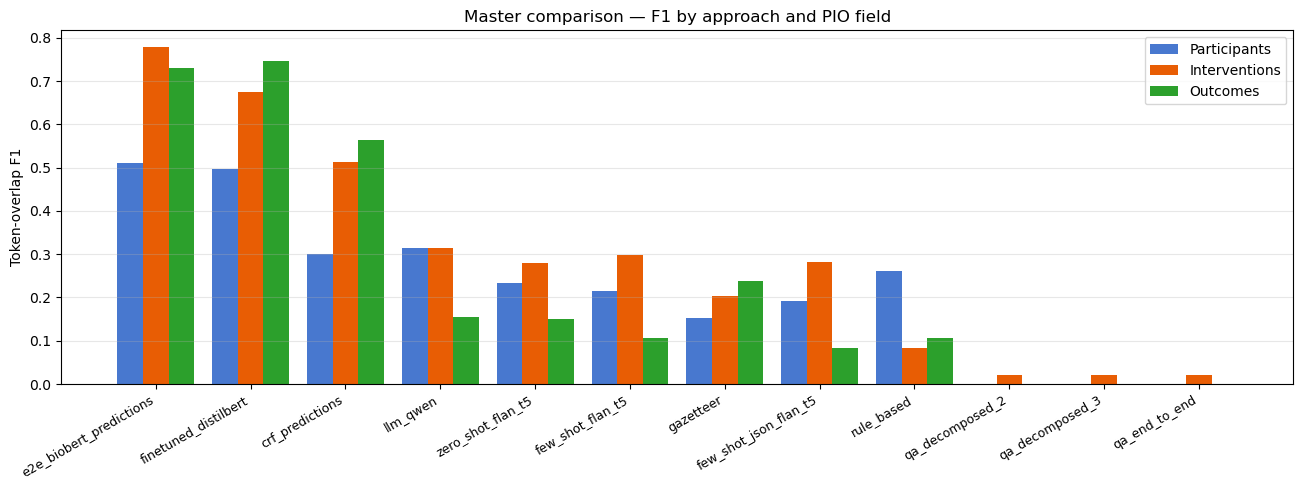

In [4]:
import matplotlib.pyplot as plt

approaches = list(predictions_by_approach.keys())
ranking = macro.index.tolist()

# F1 bar chart by approach × field
fig, ax = plt.subplots(figsize=(max(8, 0.6 * len(approaches) + 6), 5))
x = np.arange(len(ranking))
w = 0.27
colours = {'participants': '#4878CF', 'interventions': '#E85D04', 'outcomes': '#2CA02C'}

for i, field in enumerate(FIELDS):
    vals = [results_table[(results_table['approach'] == ap) & (results_table['field'] == field)]['f1'].iloc[0]
            for ap in ranking]
    ax.bar(x + (i - 1) * w, vals, w, label=field.capitalize(), color=colours[field])

ax.set_xticks(x)
ax.set_xticklabels(ranking, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Token-overlap F1')
ax.set_title('Master comparison — F1 by approach and PIO field')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('master_f1_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


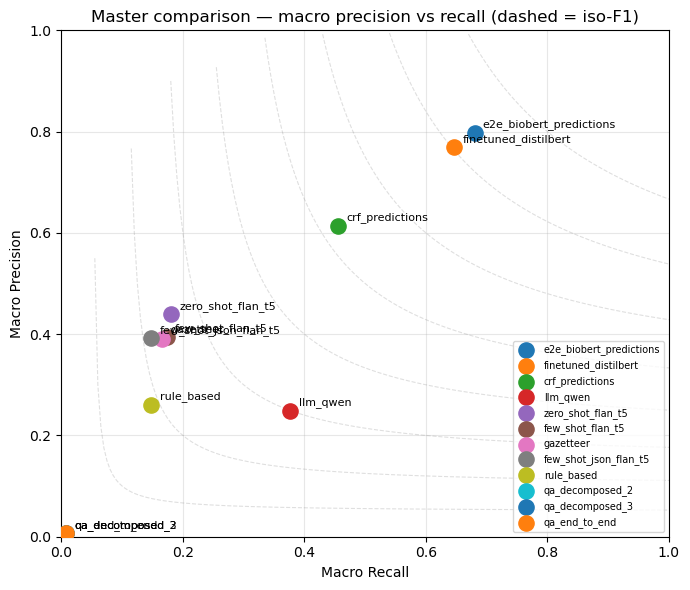

In [5]:
# Precision vs recall (macro)
fig, ax = plt.subplots(figsize=(7, 6))
cmap = plt.colormaps.get_cmap('tab10')
for i, ap in enumerate(ranking):
    p = macro.loc[ap, 'precision']
    r = macro.loc[ap, 'recall']
    ax.scatter(r, p, s=120, color=cmap(i % 10), label=ap, zorder=3)
    ax.annotate(ap, (r, p), textcoords='offset points', xytext=(6, 4), fontsize=8)

# iso-F1 curves
for f_iso in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    rs = np.linspace(0.005, 1.0, 200)
    with np.errstate(divide='ignore', invalid='ignore'):
        ps = (f_iso * rs) / (2 * rs - f_iso)
    mask = (ps > 0) & (ps <= 1)
    ax.plot(rs[mask], ps[mask], '--', color='grey', alpha=0.25, lw=0.8)

ax.set_xlim(0, 1.0); ax.set_ylim(0, 1.0)
ax.set_xlabel('Macro Recall')
ax.set_ylabel('Macro Precision')
ax.set_title('Master comparison — macro precision vs recall (dashed = iso-F1)')
ax.grid(alpha=0.3)
ax.legend(loc='lower right', fontsize=7)
plt.tight_layout()
plt.savefig('master_precision_recall.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. Downstream usability — every approach side-by-side


In [6]:
gold_per_doc = {d: {f: ' | '.join(get_gold_spans(d, f, split='test')) for f in FIELDS} for d in EVAL_IDS}

usability_rows = []
for q in run_queries(gold_per_doc):
    desc, field, kw, gold_n = q['query'], q['field'], q['keyword'], q['matches']
    for ap_name, results in predictions_by_approach.items():
        n = sum(1 for d in EVAL_IDS if kw.lower() in results.get(d, {}).get(field, '').lower())
        usability_rows.append({
            'query': desc, 'field': field, 'keyword': kw,
            'gold_matches': gold_n, 'approach': ap_name, 'pred_matches': n,
            'recall_vs_gold': n / gold_n if gold_n else 0.0,
        })

usability = pd.DataFrame(usability_rows)
print(usability.pivot_table(index='query', columns='approach', values='pred_matches', fill_value=0).to_string())
print('\nGold counts per query:')
print(usability[['query', 'gold_matches']].drop_duplicates().to_string(index=False))
usability.to_csv('master_usability.csv', index=False)


approach                    crf_predictions  e2e_biobert_predictions  few_shot_flan_t5  few_shot_json_flan_t5  finetuned_distilbert  gazetteer  llm_qwen  qa_decomposed_2  qa_decomposed_3  qa_end_to_end  rule_based  zero_shot_flan_t5
query                                                                                                                                                                                                                                   
Trials measuring pain                   4.0                      5.0               1.0                    1.0                   5.0        5.0       2.0              0.0              0.0            0.0         1.0                0.0
Trials mentioning patients              5.0                      3.0              11.0                   13.0                   4.0        1.0      27.0              0.0              0.0            0.0        25.0               19.0
Trials with placebo                    11.0                     11.0

## 5. The final PICO table — the deliverable

Build the structured PICO table from the **best** approach (highest macro
F1 in the ranking above). Save as `extracted_pico_best.csv`.

Also save a long-format CSV with every approach side-by-side
(`extracted_pico_all.csv`) so the report can reference any one of them.


In [7]:
best_approach = ranking[0]
print(f'Best approach by macro F1: {best_approach}')

# 1. Per-document PICO from best approach
pico_best = build_pico_table(best_approach, EVAL_IDS, include_abstract=True, include_gold=True, abstract_chars=400)
save_pico_table(pico_best, 'extracted_pico_best.csv')
print(f'Saved extracted_pico_best.csv with {len(pico_best)} rows')
print(pico_best.head(3).to_string(index=False))


Best approach by macro F1: e2e_biobert_predictions
Saved extracted_pico_best.csv with 50 rows
Document_ID                                                                                                                                                                                                                                                                                                                                                                                                             Abstract                                                                                        Participants                                                                Interventions                                                                                                                                       Outcomes                                                                                                                                                                          

In [8]:
# 2. Combined long-format CSV with every approach
pico_all = build_combined_pico_table(list(predictions_by_approach.keys()), EVAL_IDS)
save_pico_table(pico_all, 'extracted_pico_all.csv')
print(f'Saved extracted_pico_all.csv with {len(pico_all)} rows '
      f'({len(predictions_by_approach)} approaches × {len(EVAL_IDS)} docs)')
pico_all.head(3 * len(predictions_by_approach))[['Approach', 'Document_ID', 'Participants', 'Interventions', 'Outcomes']]


Saved extracted_pico_all.csv with 600 rows (12 approaches × 50 docs)


,Approach,Document_ID,Participants,Interventions,Outcomes
0,crf_predictions,10070173,Not Found,Not Found,Mean daily nasal symptom scores | non-nasal ad...
1,crf_predictions,10390665,aged 4-10 years | children,granisetron | perphenazine | perphenazine 70 m...,clinically serious adverse events
2,crf_predictions,10475150,primary hypothyroidism | untreated primary hyp...,somatostatin ( octreotide ) | Somatostatin | m...,GH secretion | Urinary excretion | total noctu...
3,crf_predictions,10578479,"premenopausal women | 36 premenopausal women ,...",soy intake | soy products high in isoflavonoid...,"serum estrone , estradiol , sex hormone-bindin..."
4,crf_predictions,10589810,Not Found,conventional steel or non-tooth substance remo...,bleeding on probing ( BOP ) and probing pocket...
5,crf_predictions,10763172,61 inpatients with the diagnosis Rhinitis foll...,xylometazoline | dexpanthenol | Xylometazoline...,Not Found
6,crf_predictions,10764172,Forty,Intrathecal morphine | morphine | intrathecal ...,natural killer ( NK ) cell activity | blood NK...
7,crf_predictions,10912743,hypertensive | 142 hypertensive patients ( 76 ...,aspirin | vitamin E | antihypertensive drug cl...,clinic and ambulatory blood pressure | blood p...
8,crf_predictions,10934569,children | pervasive developmental disorder | ...,intensive early intervention,Not Found
9,crf_predictions,10940525,Not Found,selamectin | selamectin treatment | ivermectin,Efficacy and safety of | flea allergy dermatit...


In [9]:
# 3. Per-approach PICO CSV — one file per approach (handy for the appendix of the report)
import os
os.makedirs('extracted_pico_per_approach', exist_ok=True)

for ap in predictions_by_approach.keys():
    df = build_pico_table(ap, EVAL_IDS, include_abstract=False, include_gold=False)
    df.to_csv(f'extracted_pico_per_approach/{ap}.csv', index=False)
print(f'Saved {len(predictions_by_approach)} per-approach PICO CSVs to ./extracted_pico_per_approach/')


Saved 12 per-approach PICO CSVs to ./extracted_pico_per_approach/


## 6. Final summary for the report

Drop these numbers straight into the experimental evaluation section.


In [10]:
print('=' * 80)
print('FINAL SUMMARY — drop into the report')
print('=' * 80)

print('\n1. Macro F1 ranking (higher is better):')
print(macro.to_string())

print('\n2. Per-field F1:')
print(wide.to_string())

print('\n3. Coverage by approach × field:')
cov_wide = results_table.pivot(index='approach', columns='field', values='coverage').round(3)
print(cov_wide.to_string())

print('\n4. Best on each field:')
for field in FIELDS:
    sub = results_table[results_table['field'] == field].nlargest(3, 'f1')
    best = sub.iloc[0]
    print(f'  {field:14s}: {best.approach} (F1={best.f1:.3f}, P={best.precision:.3f}, R={best.recall:.3f})')

print('\n5. Files written:')
for f in ['master_results_long.csv', 'master_results_wide.csv', 'master_results_macro.csv',
          'master_usability.csv', 'master_f1_comparison.png', 'master_precision_recall.png',
          'extracted_pico_best.csv', 'extracted_pico_all.csv']:
    if os.path.exists(f):
        print(f'  {f}')


FINAL SUMMARY — drop into the report

1. Macro F1 ranking (higher is better):
                         precision  recall     f1  coverage
approach                                                   
e2e_biobert_predictions      0.798   0.680  0.673     0.980
finetuned_distilbert         0.769   0.647  0.639     0.960
crf_predictions              0.614   0.455  0.459     0.773
llm_qwen                     0.249   0.377  0.261     1.000
zero_shot_flan_t5            0.439   0.181  0.221     0.600
few_shot_flan_t5             0.395   0.173  0.206     0.600
gazetteer                    0.391   0.165  0.198     0.913
few_shot_json_flan_t5        0.392   0.148  0.186     0.600
rule_based                   0.261   0.148  0.150     0.553
qa_decomposed_2              0.007   0.007  0.007     0.000
qa_decomposed_3              0.007   0.007  0.007     0.000
qa_end_to_end                0.007   0.007  0.007     0.000

2. Per-field F1:
field                    interventions  outcomes  participants
a